# Stability of Rankings LIME vs SHAP
This notebook will try and investigate the differences in the stability of the rankings produced by the two methods

In [1]:
import masking_effects_on_xai_techniques.utils as utils
import masking_effects_on_xai_techniques.plot_creator_2 as plot_creator
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
pl = plot_creator.PlotCreator(
    [
        "forest",
        "MLP",
        "knn"
    ],
    ["usa_house","usa_house_old", "cervic_cancer", "adult_imbalanced", "old_adult"],
    "../data/",
)

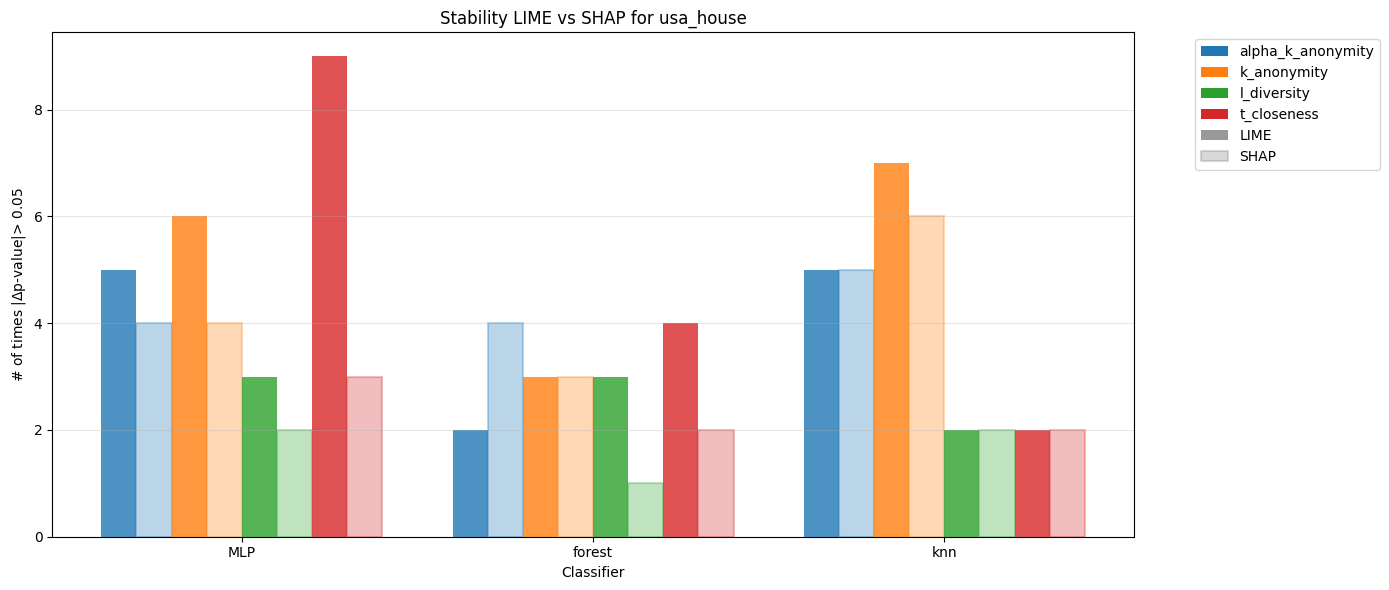

In [3]:
pl.plot_histogram("usa_house", threshold=0.05)

This shows that LIME produces rankings that tend to to change more times. Note, here we are looking at the amount of times the pvalue changes with more than 0.05. 5% has been chosen becaue it is often used in the litterature for significance measuring. If there is a p-value of 0, such a change would make the correlation not significant.  
Consider the next plot

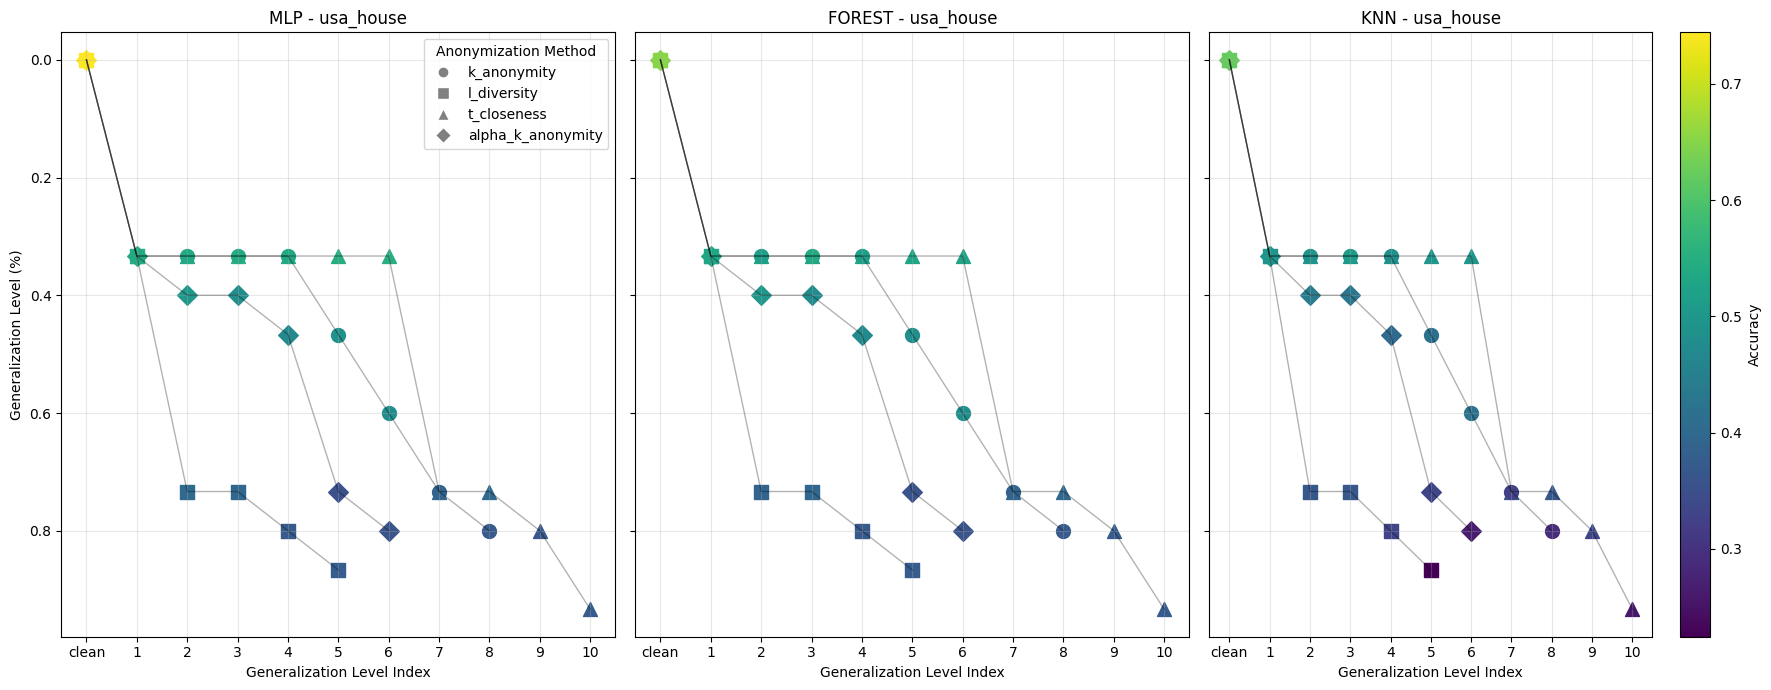

In [4]:
pl.plot_utility("usa_house", ["MLP", "forest", "knn"])

We see here that generally the accuracy falls as the data is more generalized. We also see that k_anonymity and especially t_closeness produces a dataset early that satisfy the increasing values of k and t. Also note, that it is in these that the instability of LIME specially dominates SHAP. This is however only true for MLP. Generally, the performance is affected equally

Let us consider another dataset. Note, this dataset it the only dataset that was allow to suppress 30% of it's instances

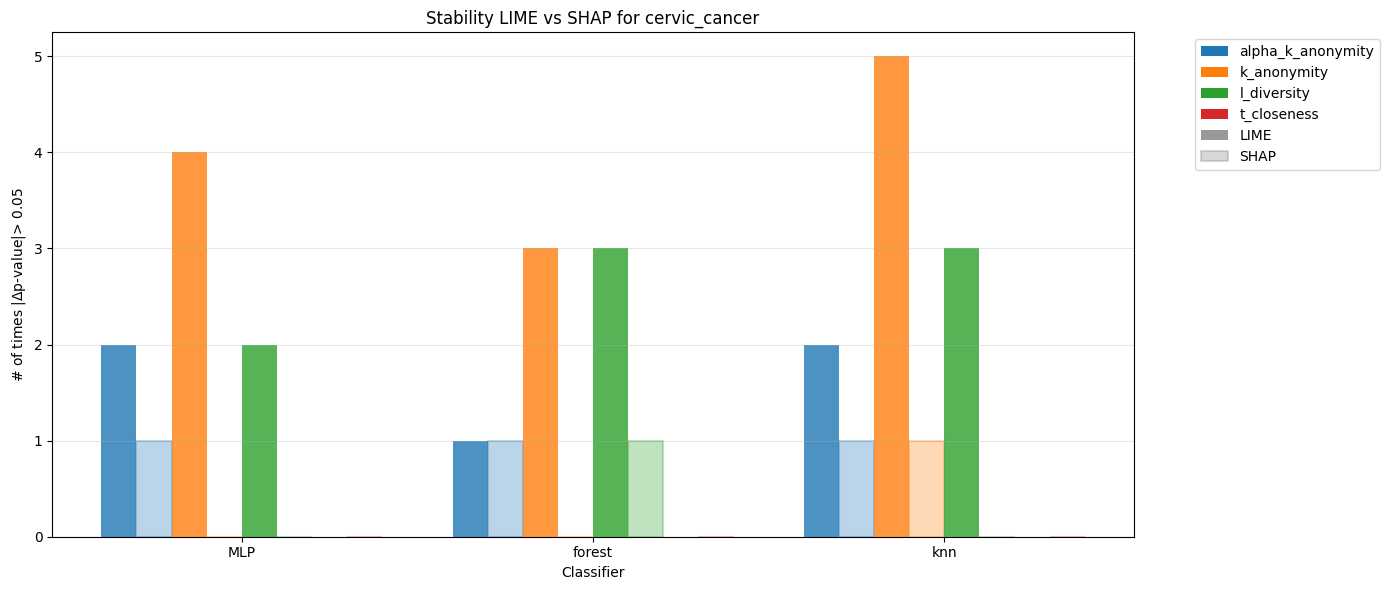

In [11]:
pl.plot_histogram("cervic_cancer", threshold=0.05)

Here it is even more evident. SHAP outperforms LIME in every model. The reason some categories are missing is because the difference is simply not that large at any time. How come?

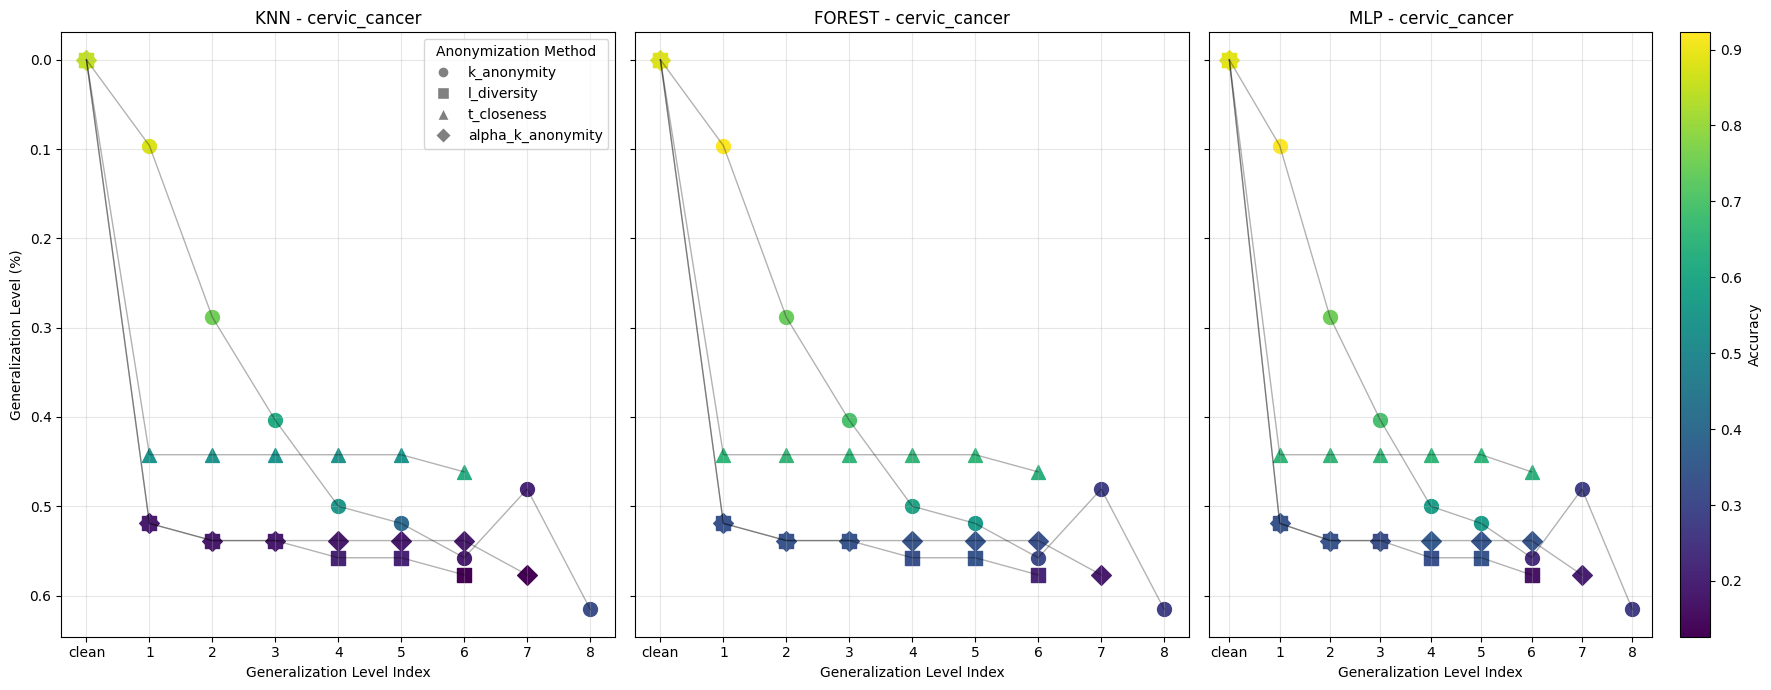

In [5]:
pl.plot_utility("cervic_cancer")

We see here that the dataset is generalized quickly 

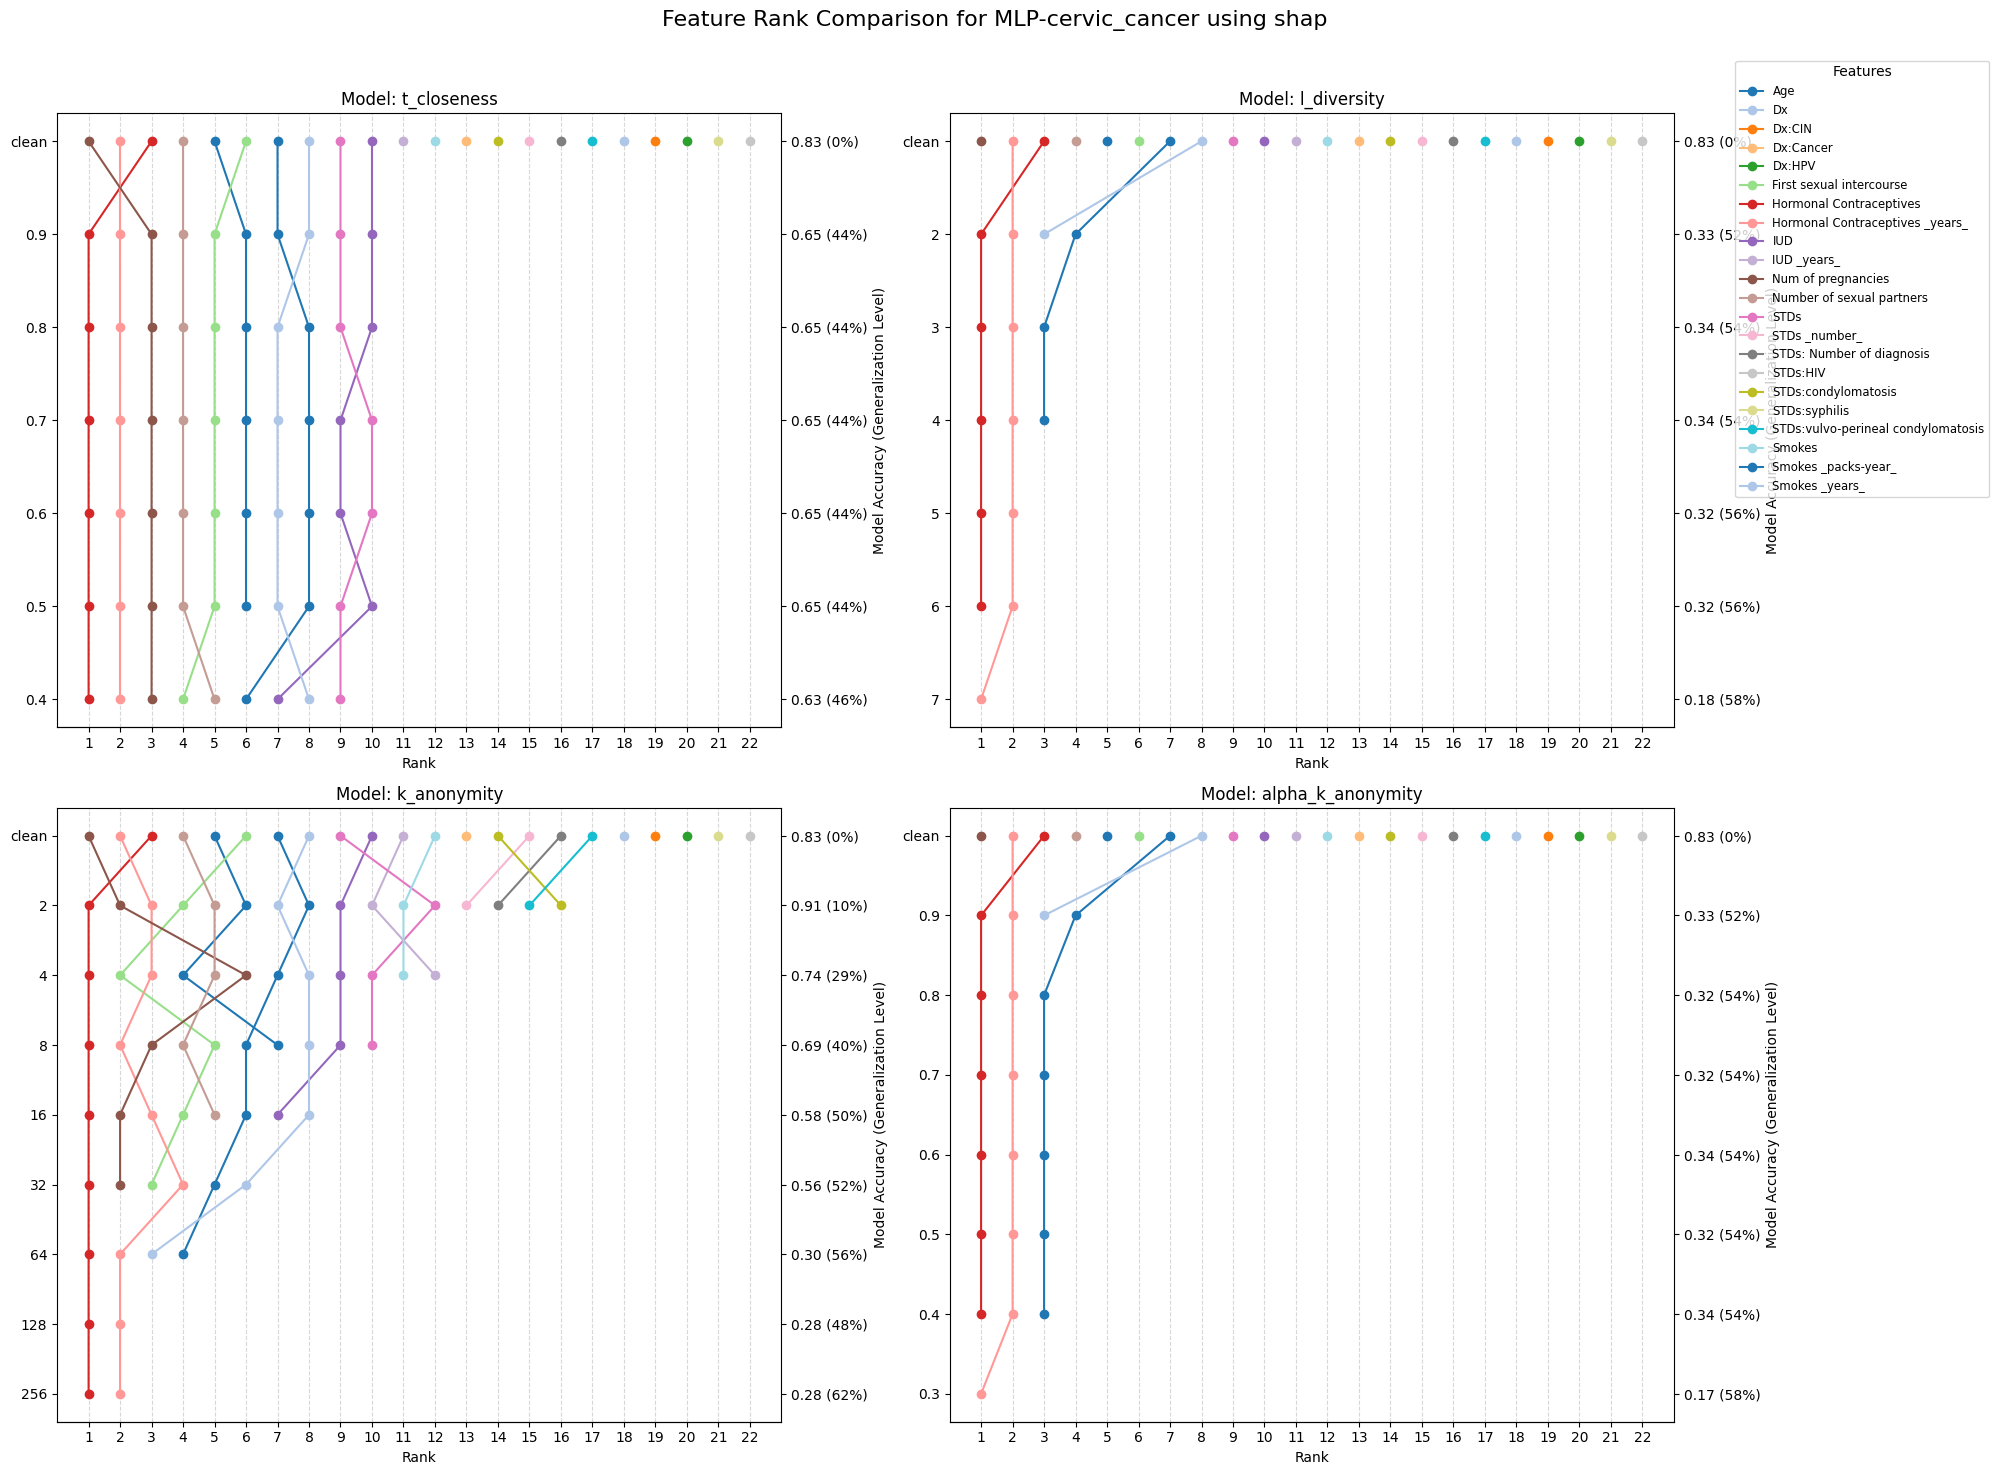

In [6]:
pl.plot_line("MLP", "cervic_cancer", "shap")

Now let us consider the adult dataset

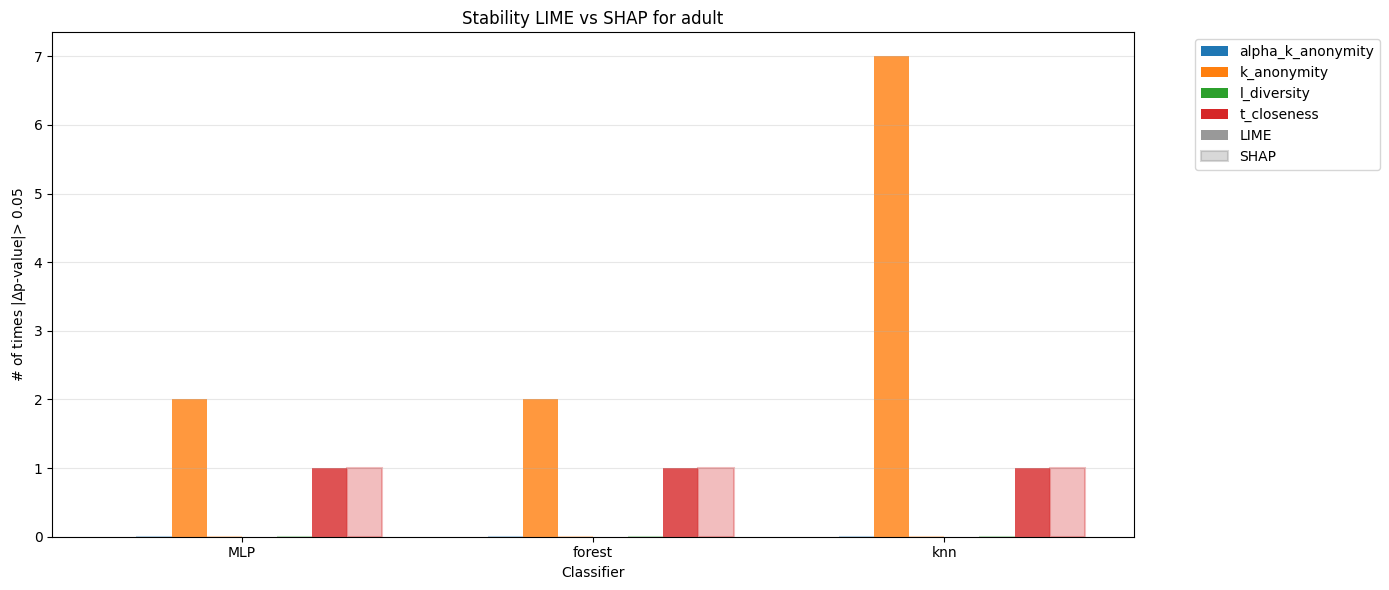

In [7]:
pl.plot_histogram("adult", threshold=0.05)

Now what is up with the lack of boxes? Easy, the Adult dataset is a binary dataset, so l_diversity can only be done once, and apparently it was not possible to make any datasets for $\alpha < 0.9$ so there is nothing to compare to. While this tells a similar story with the few bars it shows, we also se here that MLP seems to be much more stable than knn. That contradicts our previous observation that it was MLP that produced the most unstable results

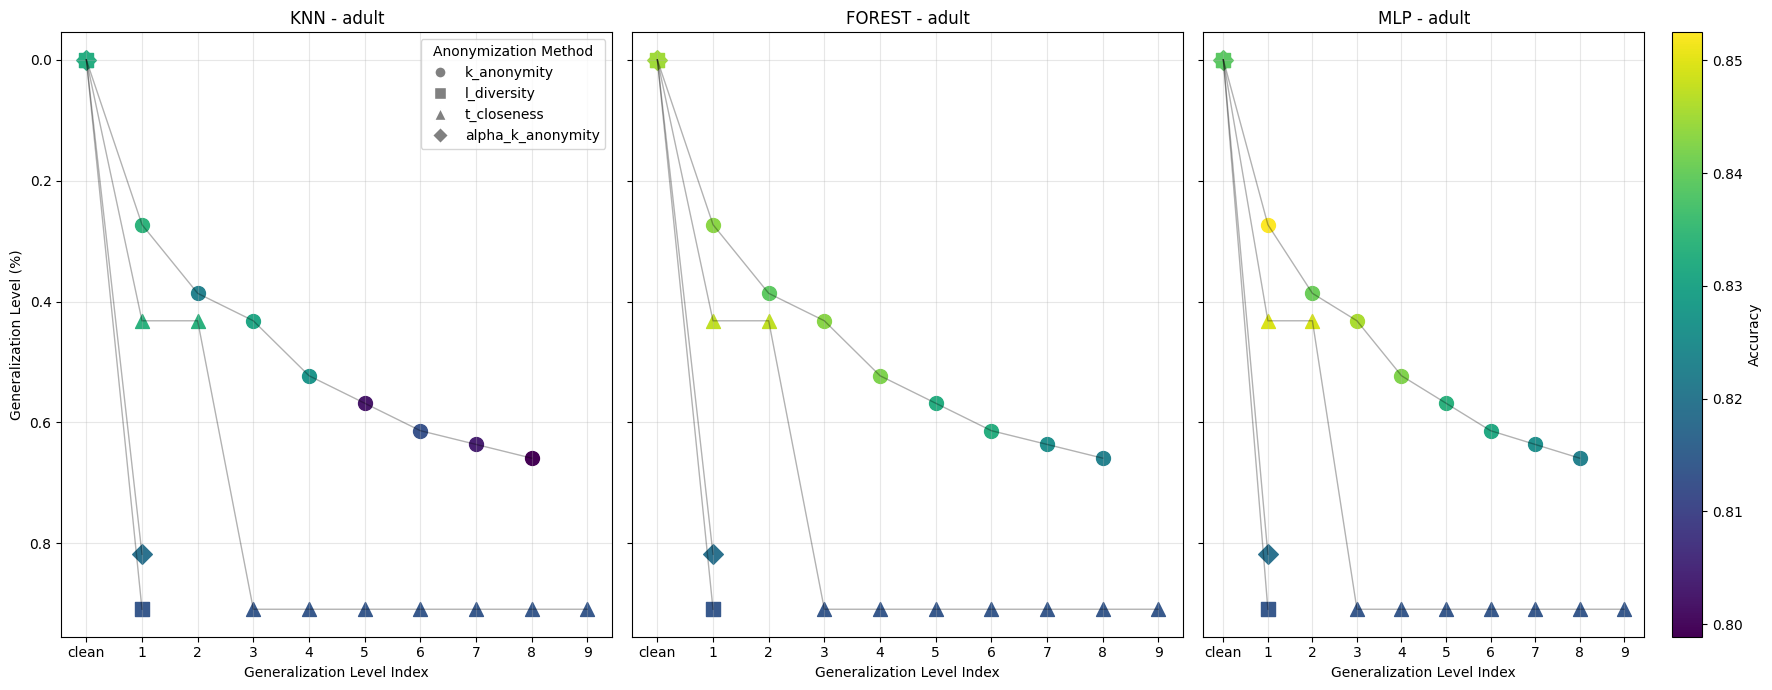

In [5]:
pl.plot_utility("adult")

Note, the accuracy is still very high. Chances are that the majority class is guessed all the time

In [7]:
pd.read_csv("../data/adult/t_closeness/0.9.csv")['income'].value_counts(normalize=True)

income
<=50K    0.816344
>50K     0.183656
Name: proportion, dtype: float64

This is very bad. I 

These plots shows that the models also react differently to the anonymization process. We see that the forest model is the only one that loses accuracy as the dataset is generalized even more. This is in stark contrast to the other datasets where all the models lost accuracy consistently as the dataset was generalized more and more. Here we see that applying the hiearchies to a specific level can change the instance space in such a way that some models do better at splitting it up.  
Another interesting thing is that t closeness anonymizes the dataset a *lot*. This works well with the fact that alpha cannot be achieved for lower values than 0.9 amd the distribution in the clean dataset is 75 vs 25